Project Work, part 1

General
All project work in IND320 will result in personal hand-ins and online apps.

A Jupyter Notebook run locally on your computer (later with access to online and local databases).
This will be your basic development and documentation platform.

Must include a brief description of AI usage.
Must include a 300-500-word log describing the compulsory work (including both Jupyter Notebook and Streamlit experience).
Must include links to your public GitHub repository and Streamlit app (see below) for the compulsory work.

Document headings should be clear and usable for navigation during development.
All code blocks must include enough comments to be understandable and reproducible if someone inherits your project.

All code blocks must be run before an export to PDF so the messages and plots are shown. In addition, add the .ipynb file to the GitHub repository where you have your Streamlit project.
A Streamlit app running at https://[yourproject].streamlit.app/.

This will be an online version of the project, accessing data that has been exported to CSV format (later, also an online database).

The code, hosted on GitHub, must include relevant comments from the Jupyter Notebook and further comments regarding Streamlit usage.

There are four parts in the project work, building on each other and resulting in a final portfolio and app to be presented at the end of the semester.

Co-operation is applauded, and the use of AI tools is encouraged.

Jupyter Notebook
Read the reservoirs.csv file using Pandas (located in D2Dbook/data).

Rename headers to English and understandable.

Print its contents in a relevant way.

Plot each column separately.

Plot all columns together. Consider how to make this natural, given that the scales are different.

Remember to fill in the log and AI mentioned in the General section above.

Importing libaries:

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

Github rep: https://github.com/IsmailNabi/IND320-prosjekt

Streamlit app: https://ismail.streamlit.app

2.1 Read the supplied data

In [8]:
df = pd.read_csv('/Users/ismailnabi/Desktop/Indøk/IND320_Prosjekt/Data/reservoirs.csv')
df.head()

,dato_Id,omrType,omrnr,iso_aar,iso_uke,fyllingsgrad,kapasitet_TWh,fylling_TWh,neste_Publiseringsdato,fyllingsgrad_forrige_uke,endring_fyllingsgrad
0,1995-09-03,EL,4,1995,35,0.944721,21.079208,19.913979,0001-01-01T00:00:00,0.936888,0.007833
1,2020-11-15,EL,1,2020,46,0.974361,6.003264,5.849344,2020-11-25T13:00:00,0.997406,-0.023046
2,2011-08-28,EL,4,2011,34,0.786499,21.079208,16.578772,0001-01-01T00:00:00,0.787193,-0.000694
3,1998-07-05,EL,3,1998,27,0.793969,8.920932,7.082947,0001-01-01T00:00:00,0.733812,0.060157
4,2011-03-27,EL,4,2011,12,0.300820,21.079208,6.341054,0001-01-01T00:00:00,0.311122,-0.010301


In [9]:
#Column mapping to rename columns for better readability
column_mapping = {
    'dato_Id': 'date',
    'omrType': 'area_type',
    'omrnr': 'area_number',
    'iso_aar': 'iso_year',
    'iso_uke': 'iso_week',
    'fyllingsgrad': 'filling_degree',
    'kapasitet_TWh': 'capacity_twh',
    'fylling_TWh': 'filling_twh',
    'neste_Publiseringsdato': 'next_publication_date',
    'fyllingsgrad_forrige_uke': 'filling_degree_prev_week',
    'endring_fyllingsgrad': 'change_filling_degree'
}

df.rename(columns=column_mapping, inplace=True)

#Convert 'date' column to datetime format for easier manipulation and analysis
df['date'] = pd.to_datetime(df['date'])

# Sort the DataFrame by date to ensure chronological order
df.sort_values('date', inplace=True)
df.reset_index(drop=True, inplace=True)

In [10]:
# Skriv ut sammendrag av datakontrakt og informasjon om dataframe
print("--- DATAFRAME INFO ---")
df.info()

print("\n--- STATISTISK OVERSIKT (NUMERISKE FELT) ---")
display(df.describe())

print("\n--- DE FØRSTE 5 RADENE ---")
display(df.head())

--- DATAFRAME INFO ---
<class 'pandas.DataFrame'>
RangeIndex: 14877 entries, 0 to 14876
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   date                      14877 non-null  datetime64[us]
 1   area_type                 14877 non-null  str           
 2   area_number               14877 non-null  int64         
 3   iso_year                  14877 non-null  int64         
 4   iso_week                  14877 non-null  int64         
 5   filling_degree            14877 non-null  float64       
 6   capacity_twh              14877 non-null  float64       
 7   filling_twh               14877 non-null  float64       
 8   next_publication_date     14877 non-null  str           
 9   filling_degree_prev_week  14877 non-null  float64       
 10  change_filling_degree     14877 non-null  float64       
dtypes: datetime64[us](1), float64(5), int64(3), str(2)
memory usage: 1.6

,date,area_number,iso_year,iso_week,filling_degree,capacity_twh,filling_twh,filling_degree_prev_week,change_filling_degree
count,14877,14877.000000,14877.000000,14877.000000,14877.000000,14877.000000,14877.000000,14877.000000,14877.000000
mean,2010-11-07 00:00:00,2.333333,2010.346038,26.405929,0.618852,29.145860,18.139713,0.618890,-0.000038
min,1995-01-08 00:00:00,0.000000,1995.000000,1.000000,0.055160,6.003264,0.331142,0.055160,-0.242484
25%,2002-12-08 00:00:00,1.000000,2002.000000,13.000000,0.456234,17.390587,7.321973,0.456356,-0.022395
50%,2010-11-07 00:00:00,2.000000,2010.000000,26.000000,0.648049,23.237715,14.501389,0.648114,-0.007072
75%,2018-10-07 00:00:00,3.000000,2018.000000,39.000000,0.802135,34.043590,22.203530,0.802133,0.016277
max,2026-09-06 00:00:00,5.000000,2026.000000,53.000000,1.020072,87.437580,84.544820,1.020037,0.336623
std,NaN,1.490762,9.146696,15.017910,0.214850,22.739070,15.966211,0.214843,0.031385



--- DE FØRSTE 5 RADENE ---


,date,area_type,area_number,iso_year,iso_week,filling_degree,capacity_twh,filling_twh,next_publication_date,filling_degree_prev_week,change_filling_degree
0,1995-01-08,EL,5,1995,1,0.616448,17.390587,10.720388,0001-01-01T00:00:00,0.614288,0.002160
1,1995-01-08,EL,4,1995,1,0.558864,21.079208,11.780413,0001-01-01T00:00:00,0.801348,-0.242484
2,1995-01-08,EL,3,1995,1,0.602376,8.920932,5.373754,0001-01-01T00:00:00,0.596027,0.006349
3,1995-01-08,EL,1,1995,1,0.621467,6.003264,3.730831,0001-01-01T00:00:00,0.734888,-0.113421
4,1995-01-08,EL,2,1995,1,0.630947,34.043590,21.479713,0001-01-01T00:00:00,0.777604,-0.146657


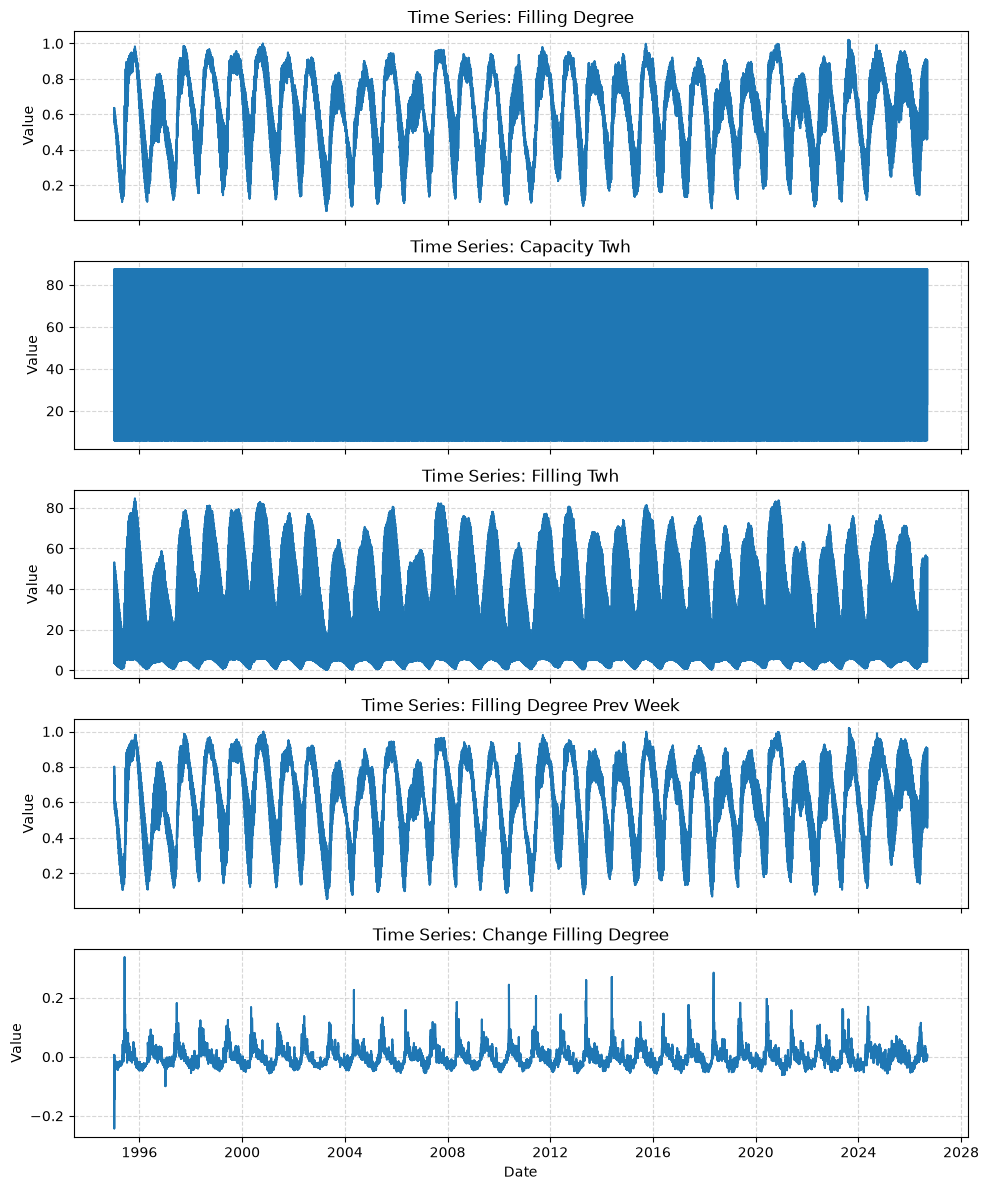

In [11]:
# Velg ut numeriske kolonner som gir mening å plotte over tid
numeric_cols = ['filling_degree', 'capacity_twh', 'filling_twh', 'filling_degree_prev_week', 'change_filling_degree']

fig, axes = plt.subplots(len(numeric_cols), 1, figsize=(10, 12), sharex=True)

for ax, col in zip(axes, numeric_cols):
    ax.plot(df['date'], df[col], label=col, color='tab:blue')
    ax.set_title(f'Time Series: {col.replace("_", " ").title()}')
    ax.set_ylabel('Value')
    ax.grid(True, linestyle='--', alpha=0.5)

axes[-1].set_xlabel('Date')
plt.tight_layout()
plt.show()

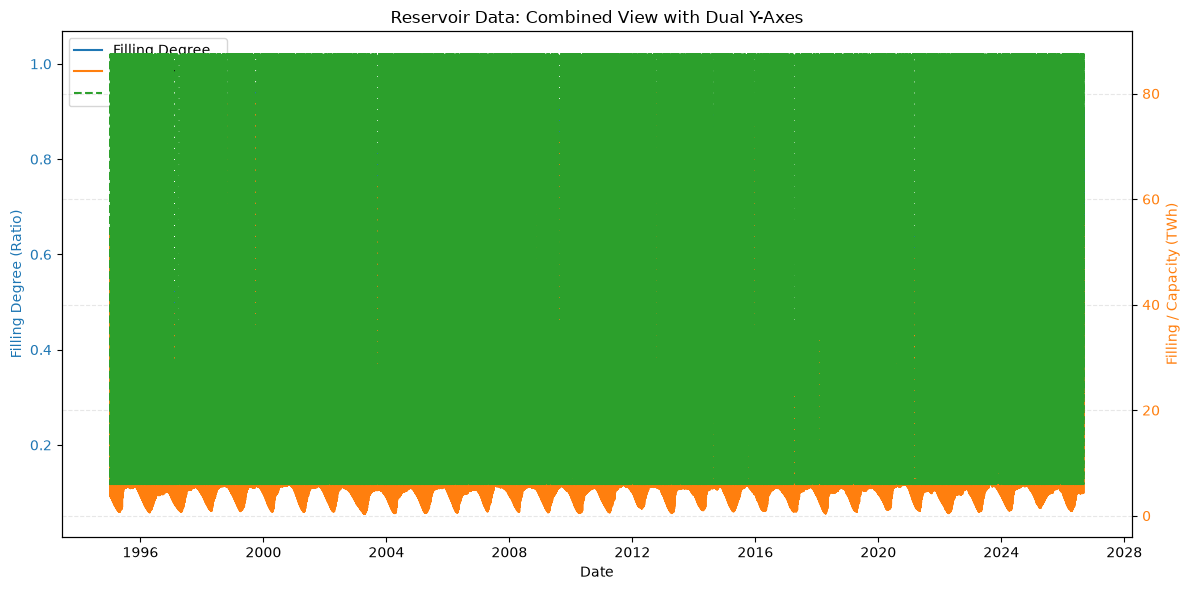

In [12]:
fig, ax1 = plt.subplots(figsize=(12, 6))

# Aksesystem 1: Fyllingsgrad (0 til 1 scale)
color = 'tab:blue'
ax1.set_xlabel('Date')
ax1.set_ylabel('Filling Degree (Ratio)', color=color)
line1 = ax1.plot(df['date'], df['filling_degree'], color=color, label='Filling Degree')
ax1.tick_params(axis='y', labelcolor=color)

# Aksesystem 2: TWh (Større skala)
ax2 = ax1.twinx()  
color = 'tab:orange'
ax2.set_ylabel('Filling / Capacity (TWh)', color=color)
line2 = ax2.plot(df['date'], df['filling_twh'], color=color, label='Filling (TWh)')
line3 = ax2.plot(df['date'], df['capacity_twh'], color='tab:green', linestyle='--', label='Capacity (TWh)')
ax2.tick_params(axis='y', labelcolor=color)

# Kombiner forklaringsskilt (legend) fra begge akser
lines = line1 + line2 + line3
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper left')

plt.title('Reservoir Data: Combined View with Dual Y-Axes')
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()